# Minimal Product: Task Integration Demand & Information Geometry
**Hypothesis:** Tasks requiring the integration of multiple streams (Context) will force the network to encode information synergistically. Simple accumulation tasks (Perceptual) will be solved redundantly. This effect should peak exactly at the end of the stimulus period.

We test this by training both an Elman RNN and a CTRNN to compare how temporal architectures affect the `gaussian_pid` structure.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy
import os

#import sys
#sys.path.append('../src/tasks') # Ensure Python can find data_loader.py
from src.tasks.data_loader import load_mante_data
from src.models.ctrnn import CTRNN
from src.models.RNN import ElmanRNN

In [ ]:
# Configuration
BASE_PATH = "../src/tasks/data/mante_style"
BATCH_SIZE = 1024 * 4
SUBSAMPLE_STEP = 1 # Subsample for Elman RNN (simulate tau=10ms)

print("Loading Perceptual Datasets...")
per_train_loader = load_mante_data(f'{BASE_PATH}/perceptual/train.npz', batch_size=BATCH_SIZE, shuffle=True, subsample_step=SUBSAMPLE_STEP)
per_val_loader = load_mante_data(f'{BASE_PATH}/perceptual/val.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)

print("Loading Context Datasets...")
ctx_train_loader = load_mante_data(f'{BASE_PATH}/context/train.npz', batch_size=BATCH_SIZE, shuffle=True, subsample_step=SUBSAMPLE_STEP)
ctx_val_loader = load_mante_data(f'{BASE_PATH}/context/val.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)

print("All datasets loaded successfully!")

Loading Perceptual Datasets...
Loading Context Datasets...
All datasets loaded successfully!


### 1. The Architectures
We define both the Elman RNN and the CTRNN. We configure both to use `batch_first=True` for easier tensor slicing, and output the full sequence of hidden states for the PID analysis.

In [3]:
class WrappedCTRNN(nn.Module):
    def __init__(self, input_dim, hidden_size, output_size=3):
        super().__init__()
        # Use the existing CTRNN
        self.model = CTRNN(input_size=input_dim, hidden_size=hidden_size, output_size=output_size)
        
    def forward(self, x):
        # CTRNN expects (Batch, Seq, Dim). 
        # We grab outputs and hidden_states, ignoring predictions.
        outputs, _, hidden_states = self.model(x, return_dynamics=True)
        return outputs, hidden_states

class WrappedElman(nn.Module):
    def __init__(self, input_dim, hidden_size, output_size=3):
        super().__init__()
        # Use ElmanRNN, override to 80 units
        self.model = ElmanRNN(dim=input_dim, hidden_dim=hidden_size)
        # Hardcoded output=input_dim. We overwrite it to 3 for our task classes.
        self.model.readout = nn.Linear(hidden_size, output_size) 
        
    def forward(self, x):
        # x is (Batch, Seq, Dim). 
        # ElmanRNN forward() assumes batch=1 and seq_first.
        # We bypass the forward() and just call the internal layers directly to support batching.
        x_seq_first = x.transpose(0, 1) # Convert to (Seq, Batch, Dim)
        
        h_seq, _ = self.model.rnn(x_seq_first) 
        outputs = self.model.readout(h_seq)
        
        # Transpose back to (Batch, Seq, Features) for the training loop
        return outputs.transpose(0, 1), h_seq.transpose(0, 1)

### 2. The Data Wrapper & Masked Loss
We implement the explicit context fix for NeuroGym and write a custom loss function that only penalizes the network during the decision period (ignoring the fixation targets of `0`).

In [4]:
def masked_cross_entropy(outputs, targets):
    """Computes loss only on the decision timesteps (where target != 0)"""
    mask = targets != 0
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True).to(outputs.device)
    
    # Flatten everything and apply the mask
    masked_outputs = outputs[mask]
    masked_targets = targets[mask]
    
    return torch.nn.functional.cross_entropy(masked_outputs, masked_targets)

### 3. The Training Loop
We will train 4 total models: Elman vs. CTRNN on Perceptual vs. Context. We train for 500 batches to get a functional Proof of Concept.

In [5]:
def train_rnn(model, train_loader, val_loader, device, num_epochs=50, lr=1e-3, patience=5, use_early_stopping=True):
    """
    Trains an RNN with validation and early stopping.
    Only computes loss during the decision period (period == 2).
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_val_loss = float('inf')
    patience_counter = 0

    # Store the initial weights just in case it completely fails to learn
    best_model_weights = copy.deepcopy(model.state_dict())
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        train_batches = 0
        
        for obs, labels, periods, cohs, ctxs in train_loader:
            obs = obs.to(device)
            labels = labels.to(device)
            periods = periods.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs, _ = model(obs) # outputs shape: (Batch, Time, Classes)
            
            # Mask for decision period
            mask = (periods == 2)
            if mask.sum() > 0:
                masked_outputs = outputs[mask]
                masked_labels = labels[mask]
                
                loss = criterion(masked_outputs, masked_labels)
                loss.backward()
                optimizer.step()
                
                running_train_loss += loss.item()
                train_batches += 1
                
        avg_train_loss = running_train_loss / max(1, train_batches)
        history['train_loss'].append(avg_train_loss)
        
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for obs, labels, periods, cohs, ctxs in val_loader:
                obs = obs.to(device)
                labels = labels.to(device)
                periods = periods.to(device)

                outputs, _ = model(obs)
                
                mask = (periods == 2)
                if mask.sum() > 0:
                    masked_outputs = outputs[mask]
                    masked_labels = labels[mask]
                    
                    loss = criterion(masked_outputs, masked_labels)
                    running_val_loss += loss.item()
                    val_batches += 1
                    
        avg_val_loss = running_val_loss / max(1, val_batches)
        history['val_loss'].append(avg_val_loss)
        
        # --- EARLY STOPPING CHECK ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Save model weights to keep the best version
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            
        # Print progress every 5 epochs
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        if use_early_stopping and patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}! Best Val Loss: {best_val_loss:.4f}")
            break

    print("Training complete. Restoring best model weights...")
    # Load the best weights back into the model before returning
    model.load_state_dict(best_model_weights)
            
    return history, model

In [8]:
# 7 input channels, 100 hidden units, 3 output choices (Fixate, Choice 1, Choice 2)
input_size = 7 
hidden_size = 100
output_size = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device.type.upper()}")
if device.type == "cuda":
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")

WEIGHTS_DIR = "../src/models/weights/mante_style"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

Using compute device: CUDA
   GPU Name: NVIDIA GeForce GTX 1080


--- Training Elman RNN on Perceptual Task ---
Epoch [001/50] | Train Loss: 0.7500 | Val Loss: 0.6963
Epoch [005/50] | Train Loss: 0.6937 | Val Loss: 0.6933
Epoch [010/50] | Train Loss: 0.6950 | Val Loss: 0.6972
Epoch [015/50] | Train Loss: 0.6930 | Val Loss: 0.6935
Early stopping triggered at epoch 19! Best Val Loss: 0.6915
Training complete. Restoring best model weights...
Saved Perceptual Model to ../src/models/weights/mante_style\elman_perceptual_best_h100.pth


--- Training Elman RNN on Context Task ---
Epoch [001/50] | Train Loss: 0.7451 | Val Loss: 0.6975
Epoch [005/50] | Train Loss: 0.6936 | Val Loss: 0.6934
Epoch [010/50] | Train Loss: 0.6937 | Val Loss: 0.6933
Epoch [015/50] | Train Loss: 0.6936 | Val Loss: 0.6944
Epoch [020/50] | Train Loss: 0.6935 | Val Loss: 0.6930
Epoch [025/50] | Train Loss: 0.6933 | Val Loss: 0.6931
Epoch [030/50] | Train Loss: 0.6930 | Val Loss: 0.6924
Epoch [035/50] | Train Loss: 0.6935 | Val Loss: 0.6930
Epoch [040/50] | Train Loss: 0.6934 | Val Loss:

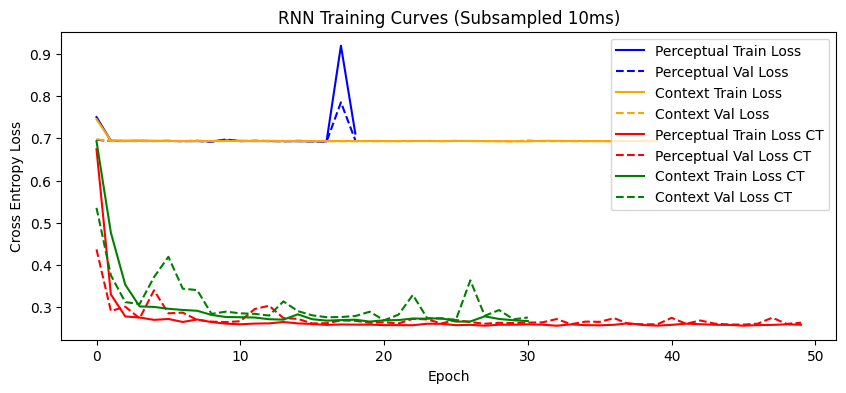

In [9]:
print("--- Training Elman RNN on Perceptual Task ---")
perceptual_model = WrappedElman(input_size, hidden_size, output_size).to(device)
per_history, perceptual_model = train_rnn(perceptual_model, per_train_loader, per_val_loader, device=device, num_epochs=50, patience=10)
perceptual_model.to('cpu')

# Save the best perceptual weights to disk
perceptual_path = os.path.join(WEIGHTS_DIR, f"elman_perceptual_best_h{hidden_size}.pth")
torch.save(perceptual_model.state_dict(), perceptual_path)
print(f"Saved Perceptual Model to {perceptual_path}\n")

print("\n--- Training Elman RNN on Context Task ---")
context_model = WrappedElman(input_size, hidden_size, output_size).to(device)
ctx_history, context_model = train_rnn(context_model, ctx_train_loader, ctx_val_loader, device=device, num_epochs=50, patience=10)
context_model.to('cpu')

# Save the best context weights to disk
context_path = os.path.join(WEIGHTS_DIR, f"elman_context_best_h{hidden_size}.pth")
torch.save(context_model.state_dict(), context_path)
print(f"Saved Context Model to {context_path}\n")

print("\n--- Training CTRNN on Perceptual Task ---")
perceptual_model_2 = WrappedCTRNN(input_size, hidden_size, output_size).to(device)
per_history_2, perceptual_model_2 = train_rnn(perceptual_model_2, per_train_loader, per_val_loader, device=device, num_epochs=50, patience=10)
perceptual_model_2.to('cpu')

# Save the best perceptual weights to disk
perceptual_path = os.path.join(WEIGHTS_DIR, f"ctrnn_perceptual_best_h{hidden_size}.pth")
torch.save(perceptual_model_2.state_dict(), perceptual_path)
print(f"Saved Perceptual Model to {perceptual_path}\n")

print("\n--- Training CTRNN on Context Task ---")
context_model_2 = WrappedCTRNN(input_size, hidden_size, output_size).to(device)
ctx_history_2, context_model_2 = train_rnn(context_model_2, ctx_train_loader, ctx_val_loader, device=device, num_epochs=50, patience=10)
context_model_2.to('cpu')

# Save the best context weights to disk
context_path = os.path.join(WEIGHTS_DIR, f"ctrnn_context_best_h{hidden_size}.pth")
torch.save(context_model_2.state_dict(), context_path)
print(f"Saved Context Model to {context_path}\n")

In [ ]:
# Plot the training curves
plt.figure(figsize=(10, 4))
plt.plot(per_history['train_loss'], label='Perceptual Train Loss', color='blue')
plt.plot(per_history['val_loss'], label='Perceptual Val Loss', color='blue', linestyle='--')
plt.plot(ctx_history['train_loss'], label='Context Train Loss', color='orange')
plt.plot(ctx_history['val_loss'], label='Context Val Loss', color='orange', linestyle='--')
plt.plot(per_history_2['train_loss'], label='Perceptual Train Loss CT', color='red')
plt.plot(per_history_2['val_loss'], label='Perceptual Val Loss CT', color='red', linestyle='--')
plt.plot(ctx_history_2['train_loss'], label='Context Train Loss CT', color='green')
plt.plot(ctx_history_2['val_loss'], label='Context Val Loss CT', color='green', linestyle='--')
plt.title("RNN Training Curves")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.show()

### 4. Time-Resolved PID Analysis
We generate a large testing ensemble (200 trials), run them through the trained networks without updating weights, and calculate the Gaussian PID at *every single timestep*. We use the final trial choice as the target variable for the PID.

In [10]:
def extract_hidden_trajectories(model, dataloader):
    """
    Runs the dataset through the model and extracts the hidden state, target, and context 
    at every timestep for every trial.
    """
    model.eval()
    all_hidden = []
    all_targets = []
    all_periods = []
    all_ctxs = []
    
    with torch.no_grad():
        for obs, labels, periods, cohs, ctxs in dataloader:
            # We bypass the final linear layer and get the raw hidden states
            # Standard nn.RNN returns (output, h_n). 'output' contains all timesteps.
            _, hidden_states = model(obs) 
            
            all_hidden.append(hidden_states.numpy())

            # Using mean coherence as our target!
            if cohs.ndim > 1:
                all_targets.append(cohs[:, 0].numpy().astype(float))
            else:
                all_targets.append(cohs.numpy().astype(float))
            # Using continuous noisy coherence as our target
            #noisy_evidence = obs[:, :, 1] - obs[:, :, 2]
            #all_targets.append(noisy_evidence.numpy().astype(float)) 
            
            # Using labels as our target!
            #all_targets.append(labels[:, -1].numpy().astype(float)) 
            

            all_periods.append(periods.numpy())

            all_ctxs.append(ctxs.numpy())
            
    # Concatenate across batches
    H = np.concatenate(all_hidden, axis=0)      # Shape: (Trials, Timesteps, Hidden_Size)
    Y = np.concatenate(all_targets, axis=0)     # Shape: (Trials,)
    P = np.concatenate(all_periods, axis=0)     # Shape: (Trials, Timesteps)
    C = np.concatenate(all_ctxs, axis=0)        # Shape: (Trials,)
    
    return H, Y, P, C

In [15]:
print("Extracting hidden state trajectories for the Test Sets...")

# Load the dedicated Test Sets (never seen during training or validation!)
#TEST_SET = "test_mante"
TEST_SET = "test_01"
per_test_loader = load_mante_data(f'{BASE_PATH}/perceptual/{TEST_SET}.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)
ctx_test_loader = load_mante_data(f'{BASE_PATH}/context/{TEST_SET}.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)

# Load models from savepoints (optional)
perceptual_model_elman = WrappedElman(input_size, hidden_size, output_size)
perceptual_model_elman.load_state_dict(torch.load(f"{WEIGHTS_DIR}/elman_perceptual_best_h{hidden_size}.pth", weights_only=True))
context_model_elman = WrappedElman(input_size, hidden_size, output_size)
context_model_elman.load_state_dict(torch.load(f"{WEIGHTS_DIR}/elman_context_best_h{hidden_size}.pth", weights_only=True))

perceptual_model_ctrnn = WrappedCTRNN(input_size, hidden_size, output_size)
perceptual_model_ctrnn.load_state_dict(torch.load(f"{WEIGHTS_DIR}/ctrnn_perceptual_best_h{hidden_size}.pth", weights_only=True))
context_model_ctrnn = WrappedCTRNN(input_size, hidden_size, output_size)
context_model_ctrnn.load_state_dict(torch.load(f"{WEIGHTS_DIR}/ctrnn_context_best_h{hidden_size}.pth", weights_only=True))

# Extract Trajectories
H_per_elman, Y_per_elman, P_per_elman, C_per_elman = extract_hidden_trajectories(perceptual_model_elman, per_test_loader)
H_ctx_elman, Y_ctx_elman, P_ctx_elman, C_ctx_elman = extract_hidden_trajectories(context_model_elman, ctx_test_loader)

H_per_ctrnn, Y_per_ctrnn, P_per_ctrnn, C_per_ctrnn = extract_hidden_trajectories(perceptual_model_ctrnn, per_test_loader)
H_ctx_ctrnn, Y_ctx_ctrnn, P_ctx_ctrnn, C_ctx_ctrnn = extract_hidden_trajectories(context_model_ctrnn, ctx_test_loader)

print(f"Perceptual Trajectories Shape: {H_per_elman.shape}")
print(f"Context Trajectories Shape:    {H_ctx_elman.shape}")

Extracting hidden state trajectories for the Test Sets...
Perceptual Trajectories Shape: (2000, 115, 100)
Context Trajectories Shape:    (2000, 115, 100)


In [16]:
if len(Y_ctx_ctrnn.shape) > 1:
    print(f"{Y_ctx_ctrnn[:10, 24:-9]=}")
else:
    print(f"{Y_ctx_ctrnn[:100]=}")

Y_ctx_ctrnn[:100]=array([  1.91326535,  -6.88775492, -14.15816307,  -6.88775492,
        14.92346954,  -7.27040815,  -2.29591846,  18.36734772,
         7.27040815, -12.24489784, -10.71428585,  -3.06122446,
       -11.09693909,  11.86224461,  12.62755108,   0.        ,
        11.86224461,  16.45408249,  13.01020432,  13.39285755,
        -1.53061223,   5.73979568,  -9.94897938,   9.56632614,
       -16.45408249, -17.60204124,  -0.76530612, -17.60204124,
        17.60204124,  17.60204124, -17.60204124,   3.06122446,
       -16.83673477,  -1.91326535,   6.50510216,  13.77550983,
       -13.01020432,  -5.73979568,  13.39285755, -15.68877506,
         1.91326535,  -8.03571415,  15.68877506,   7.65306139,
         3.44387746,  -1.53061223,   9.94897938,  -3.82653069,
        -4.97448969,   4.20918369, -13.39285755,  -7.27040815,
        -7.65306139,  -6.88775492,   2.29591846,  -4.59183693,
         5.35714293,  17.60204124,  12.24489784,  12.62755108,
        -9.18367386,   3.82653069,  1

In [17]:
import numpy as np
from src.analysis.gaussian_pid import gaussian_pid_rnn

mask_per_c1 = (C_per_elman == 1)
mask_ctx_c1 = (C_ctx_elman == 1)

# masking
# H_per_elman = H_per_elman[mask_per_c1]
# Y_per_elman = Y_per_elman[mask_per_c1]

# H_ctx_elman = H_ctx_elman[mask_ctx_c1]
# Y_ctx_elman = Y_ctx_elman[mask_ctx_c1]

# H_per_ctrnn = H_per_ctrnn[mask_per_c1]
# Y_per_ctrnn = Y_per_ctrnn[mask_per_c1]

# H_ctx_ctrnn = H_ctx_ctrnn[mask_ctx_c1]
# Y_ctx_ctrnn = Y_ctx_ctrnn[mask_ctx_c1]

# Run the analysis (Warning: This might take a few minutes!)
print("Analyzing Perceptual Elman Network...")
pid_elman_perceptual = gaussian_pid_rnn(
    activations=H_per_elman,
    target=Y_per_elman, 
    timestep=None,           
    bipartitions="random",
    n_bipartitions=200,
    seed=42,
    log_base=2,
    regularization=1e-5
)

print("Analyzing Context Elman Network...")
pid_elman_context = gaussian_pid_rnn(
    activations=H_ctx_elman,
    target=Y_ctx_elman, 
    timestep=None,           
    bipartitions="random",
    n_bipartitions=200,
    seed=42,
    log_base=2,
    regularization=1e-5
)

print("Analyzing Perceptual CTRNN Network...")
pid_ctrnn_perceptual = gaussian_pid_rnn(
    activations=H_per_ctrnn,
    target=Y_per_ctrnn, 
    timestep=None,           
    bipartitions="random",
    n_bipartitions=200,
    seed=42,
    log_base=2,
    regularization=1e-5
)

print("Analyzing Context CTRNN Network...")
pid_ctrnn_context = gaussian_pid_rnn(
    activations=H_ctx_ctrnn,
    target=Y_ctx_ctrnn, 
    timestep=None,           
    bipartitions="random",
    n_bipartitions=200,
    seed=42,
    log_base=2,
    regularization=1e-5
)

print("Succesfully calculated PID metrics")

Analyzing Perceptual Elman Network...
Analyzing Context Elman Network...
Analyzing Perceptual CTRNN Network...
Analyzing Context CTRNN Network...
Succesfully calculated PID metrics


### 5. Evaluating the Hypothesis (Visualization)
We plot the Synergy and Redundancy tracks. According to our hypothesis:
1. Synergy should peak around the dotted vertical line (end of stimulus).
2. The Context task (bottom row) should have significantly higher Synergy than the Perceptual task (top row).

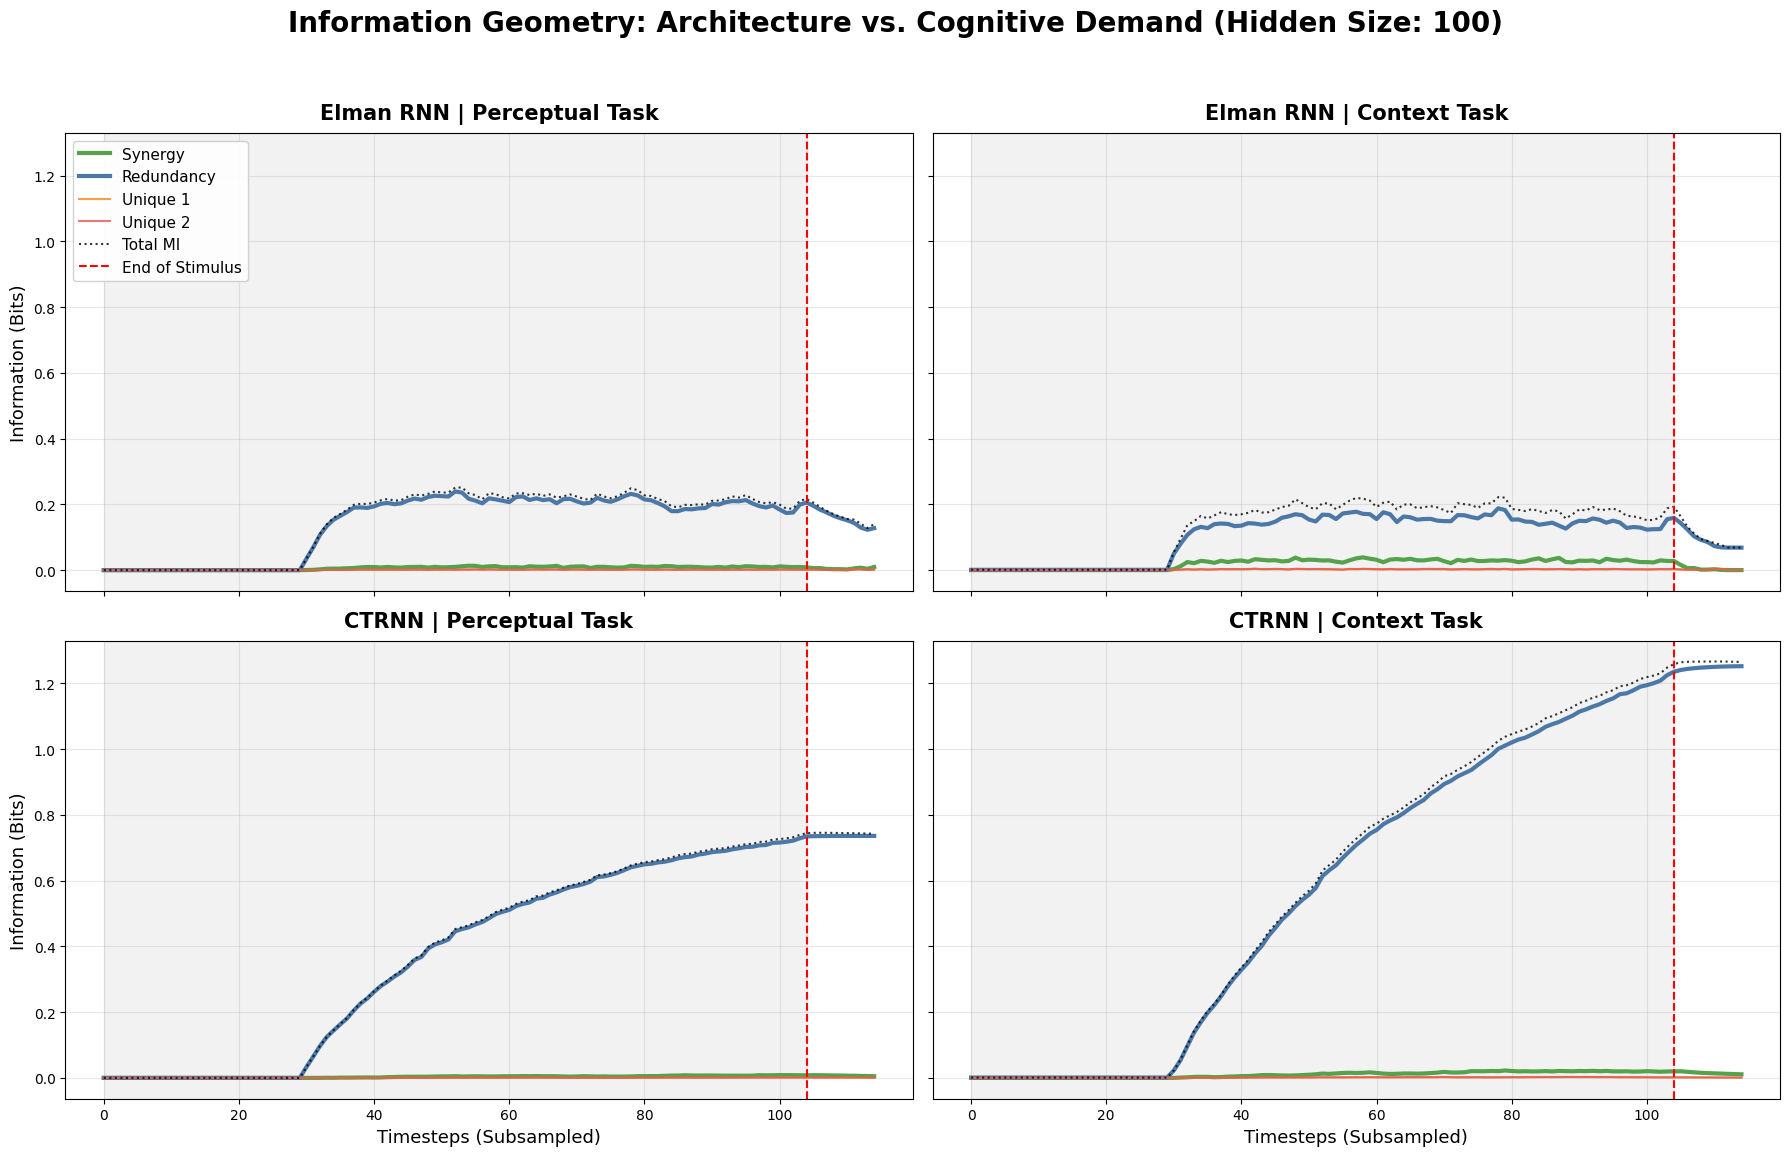

In [18]:
# Dynamically find the End of Stimulus index (same across all models/tasks)
stim_end_idx = np.where(P_ctx_elman[0] == 1)[0][-1] 

# Define the grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True, sharex=True)

# Add an overarching title to the entire figure specifying the hidden size
fig.suptitle(f"Information Geometry: Architecture vs. Cognitive Demand (Hidden Size: {hidden_size})", 
             fontsize=20, fontweight='bold', y=0.96)

def plot_pid_ax(ax, data, title):
    """Helper function to plot PID lines on a specific subplot axis."""
    time_axis = np.arange(len(data['synergy']))
    
    ax.plot(time_axis, data['synergy'], label='Synergy', color='#54A24B', linewidth=3)
    ax.plot(time_axis, data['redundancy'], label='Redundancy', color='#4C78A8', linewidth=3)
    ax.plot(time_axis, data['unique1'], label='Unique 1', color='#F58518', linewidth=1.5, alpha=0.8)
    ax.plot(time_axis, data['unique2'], label='Unique 2', color='#E45756', linewidth=1.5, alpha=0.8)
    ax.plot(time_axis, data['mi_joint'], label='Total MI', color='#020202', linewidth='1.5', alpha=0.8, linestyle=':')
    
    # Mark the End of Stimulus
    ax.axvline(stim_end_idx, color='red', linestyle='--', label='End of Stimulus')
    ax.axvspan(0, stim_end_idx, color='gray', alpha=0.1)
    
    ax.set_title(title, fontsize=15, fontweight='bold', pad=10)
    ax.grid(alpha=0.3)
    
    # Only show axis labels on the outer edges to keep it clean
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Information (Bits)', fontsize=13)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel('Timesteps (Subsampled)', fontsize=13)

# --- Row 1: Elman RNN ---
plot_pid_ax(axes[0, 0], pid_elman_perceptual, "Elman RNN | Perceptual Task")
plot_pid_ax(axes[0, 1], pid_elman_context, "Elman RNN | Context Task")

# --- Row 2: CTRNN ---
plot_pid_ax(axes[1, 0], pid_ctrnn_perceptual, "CTRNN | Perceptual Task")
plot_pid_ax(axes[1, 1], pid_ctrnn_context, "CTRNN | Context Task")

# Add a single master legend to the first plot
axes[0, 0].legend(loc='upper left', fontsize=11, framealpha=0.9)

# Adjust spacing so the main title doesn't overlap with the subplot titles
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()